In [6]:
import os
os.chdir('case-study')

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [8]:
data = pd.read_excel("data/view_export_messungen_2006-11-08.xls")

In [9]:
data['age'] = 2006 - data['geburtsjahr']

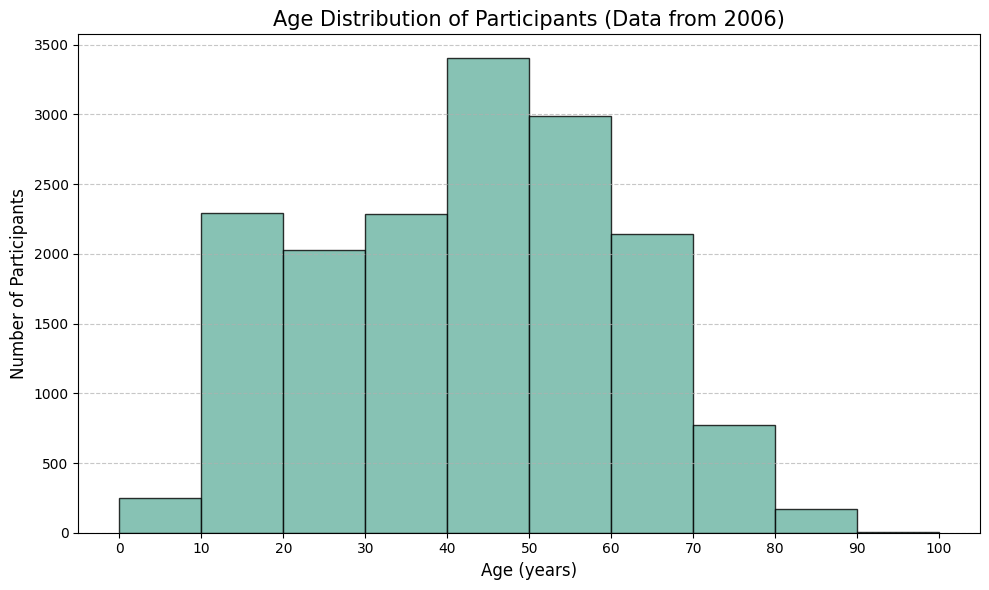

In [10]:
plt.figure(figsize=(10, 6))
n, bins, patches = plt.hist(
    data['age'],
    bins=[0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100],
    color='#69b3a2',
    edgecolor='black',
    alpha=0.8
)
plt.title('Age Distribution of Participants (Data from 2006)', fontsize=15)
plt.xlabel('Age (years)', fontsize=12)
plt.ylabel('Number of Participants', fontsize=12)
plt.xticks(bins)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Health condition value counts:
 befinden
1.0    5897
2.0    7931
3.0    2240
4.0     198
5.0      97
Name: count, dtype: int64

Gender value counts:
 geschlecht
f    9190
m    7173
Name: count, dtype: int64

Percentage distribution of health condition by gender:
 geschlecht     f     m
befinden              
1.0         35.4  36.8
2.0         48.2  48.8
3.0         14.8  12.3
4.0          1.2   1.2
5.0          0.4   0.8


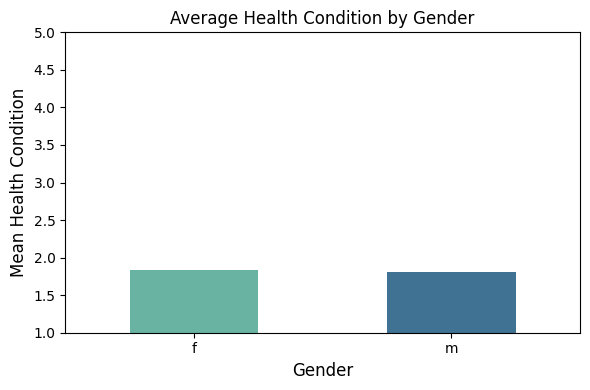

In [12]:
# Exploratory analysis: Relationship between health condition and gender

# Value counts for 'befinden' (health condition)
print("Health condition value counts:\n", data['befinden'].value_counts().sort_index())

# Value counts for 'geschlecht' (gender)
print("\nGender value counts:\n", data['geschlecht'].value_counts())

# Cross-tabulation of health condition by gender
befinden_gender_ct = pd.crosstab(data['befinden'], data['geschlecht'], normalize='columns') * 100
print("\nPercentage distribution of health condition by gender:\n", befinden_gender_ct.round(1))

# Bar plot: Mean health condition by gender (lower is better)
mean_befinden_by_gender = data.groupby('geschlecht')['befinden'].mean()
plt.figure(figsize=(6, 4))
mean_befinden_by_gender.plot(kind='bar', color=['#69b3a2', '#407294'])
plt.ylabel('Mean Health Condition', fontsize=12)
plt.xlabel('Gender', fontsize=12)
plt.title('Average Health Condition by Gender')
plt.xticks(rotation=0)
plt.ylim(1, 5)
plt.tight_layout()
plt.show()